<a href="https://colab.research.google.com/github/hmdaalln/Group7/blob/main/Copy_of_ass4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
import torch
import torchvision
import torchvision.transforms as transforms
import torch.nn as nn
import torch.nn.functional as F
import torch.optim as optim
import torchvision.models as models
import cv2
from matplotlib import pyplot as plt
device = torch.device("cuda:0" if torch.cuda.is_available() else "cpu")

In [ ]:
batch_size = 128


In [ ]:

transform = transforms.Compose(
    [transforms.ToTensor()])


In [ ]:
import torchvision.transforms as T

# CIFAR-100 normalization values
MEAN = (0.5071, 0.4867, 0.4408)
STD  = (0.2675, 0.2565, 0.2761)

# Define transforms for training and testing
train_tfms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

test_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# Also define a batch size if not done
BATCH_SIZE = 128


In [ ]:
# if you already have: import torchvision.transforms as T
# and defined train_tfms / test_tfms and BATCH_SIZE

trainset = torchvision.datasets.CIFAR100(root='./cifar_100', train=True,
                                         download=True, transform=train_tfms)
train_loader = torch.utils.data.DataLoader(trainset, batch_size=BATCH_SIZE,
                                           shuffle=True, num_workers=2)

testset = torchvision.datasets.CIFAR100(root='./cifar_100', train=False,
                                        download=True, transform=test_tfms)
test_loader = torch.utils.data.DataLoader(testset, batch_size=BATCH_SIZE,
                                          shuffle=False, num_workers=2)

classes = trainset.classes  # official CIFAR-100 class names


classes = [
    'apple', 'aquarium_fish', 'baby', 'bear', 'beaver', 'bed', 'bee', 'beetle', 'bicycle', 'bottle',
    'bowl', 'boy', 'bridge', 'bus', 'butterfly', 'camel', 'can', 'castle', 'caterpillar', 'cattle',
    'chair', 'chimpanzee', 'clock', 'cloud', 'cockroach', 'couch', 'crab', 'crocodile', 'cup',
    'dinosaur', 'dolphin', 'elephant', 'flatfish', 'forest', 'fox', 'girl', 'hamster', 'house',
    'kangaroo', 'keyboard', 'lamp', 'lawn_mower', 'leopard', 'lion', 'lizard', 'lobster', 'man',
    'maple_tree', 'motorcycle', 'mountain', 'mouse', 'mushroom', 'oak_tree', 'orange', 'orchid',
    'otter', 'palm_tree', 'pear', 'pickup_truck', 'pine_tree', 'plain', 'plate', 'poppy', 'porcupine',
    'possum', 'rabbit', 'raccoon', 'ray', 'road', 'rocket', 'rose', 'sea', 'seal', 'shark', 'shrew',
    'skunk', 'skyscraper', 'snail', 'snake', 'spider', 'squirrel', 'streetcar', 'sunflower',
    'sweet_pepper', 'table', 'tank', 'telephone', 'television', 'tiger', 'tractor', 'train',
    'trout', 'tulip', 'turtle', 'wardrobe', 'whale', 'willow_tree', 'wolf', 'woman', 'worm'
]

In [ ]:
import torch
import torch.nn as nn
from torchvision import models

class ResNet18CustomInput(nn.Module):
    def __init__(self, num_classes=100, input_channels=3):
        super(ResNet18CustomInput, self).__init__()

        # Load pre-trained ResNet-18
        self.resnet = models.resnet18(weights=models.ResNet18_Weights.DEFAULT)

        # Modify first conv layer for CIFAR input
        self.resnet.conv1 = nn.Conv2d(input_channels, 64, kernel_size=3, stride=1, padding=1, bias=False)
        self.resnet.maxpool = nn.Identity()  # remove large 7x7 downsampling

        # Replace FC layer for CIFAR-100
        in_features = self.resnet.fc.in_features  # 512 for ResNet-18
        self.resnet.fc = nn.Linear(in_features, num_classes)

    def forward(self, x):
        return self.resnet(x)

# Instantiate and move to GPU
num_classes = 100
input_channels = 3
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

model = ResNet18CustomInput(num_classes, input_channels).to(device)
print("✅ ResNet-18 for CIFAR-100 ready on", device)


✅ ResNet-18 for CIFAR-100 ready on cuda


In [ ]:
criterion = nn.CrossEntropyLoss()
optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)


In [ ]:
def train(model, train_loader, optimizer, criterion, epoch):
    model.train()
    for batch_idx, data in enumerate(train_loader):
        inputs, labels = data
        inputs, labels = inputs.to(device), labels.to(device)

        optimizer.zero_grad()
        output = model(inputs)
        loss = criterion(output, labels)
        loss.backward()
        optimizer.step()

        if batch_idx % 100 == 0:
            print('Train Epoch: {} [{}/{} ({:.0f}%)]\tLoss: {:.6f}'.format(
                epoch,
                batch_idx * len(inputs),
                len(train_loader.dataset),
                100. * batch_idx / len(train_loader),
                loss.item()
            ))


In [ ]:
def test(model, test_loader):
    model.eval()
    test_loss = 0.0
    correct = 0
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs, labels = inputs.to(device), labels.to(device)
            output = model(inputs)
            loss = criterion(output, labels)
            test_loss += loss.item() * inputs.size(0)  # multiply by batch size
            pred = output.argmax(dim=1, keepdim=True)
            correct += pred.eq(labels.view_as(pred)).sum().item()

    test_loss /= len(test_loader.dataset)
    accuracy = 100. * correct / len(test_loader.dataset)
    print('\nTest set: Average loss: {:.4f}, Accuracy: {}/{} ({:.2f}%)\n'.format(
        test_loss, correct, len(test_loader.dataset), accuracy))

    return test_loss, accuracy


In [ ]:
epochs = 50
for epoch in range(1, epochs + 1):
    train(model, train_loader, optimizer, criterion, epoch)
    test(model, test_loader)
    torch.save(model.state_dict(), 'cifar100_resnet18_model.pth')
    print('model saved')

Train Epoch: 1 [0/50000 (0%)]	Loss: 4.901207
Train Epoch: 1 [12800/50000 (26%)]	Loss: 2.899322
Train Epoch: 1 [25600/50000 (51%)]	Loss: 2.084382
Train Epoch: 1 [38400/50000 (77%)]	Loss: 1.490036

Test set: Average loss: 1.5841, Accuracy: 5551/10000 (55.51%)

model saved
Train Epoch: 2 [0/50000 (0%)]	Loss: 1.689013
Train Epoch: 2 [12800/50000 (26%)]	Loss: 1.350726
Train Epoch: 2 [25600/50000 (51%)]	Loss: 1.247113
Train Epoch: 2 [38400/50000 (77%)]	Loss: 1.220069

Test set: Average loss: 1.2834, Accuracy: 6295/10000 (62.95%)

model saved
Train Epoch: 3 [0/50000 (0%)]	Loss: 1.119861
Train Epoch: 3 [12800/50000 (26%)]	Loss: 1.067837
Train Epoch: 3 [25600/50000 (51%)]	Loss: 0.849518
Train Epoch: 3 [38400/50000 (77%)]	Loss: 0.968110

Test set: Average loss: 1.1246, Accuracy: 6775/10000 (67.75%)

model saved
Train Epoch: 4 [0/50000 (0%)]	Loss: 0.721207
Train Epoch: 4 [12800/50000 (26%)]	Loss: 0.822557
Train Epoch: 4 [25600/50000 (51%)]	Loss: 0.766222
Train Epoch: 4 [38400/50000 (77%)]	Loss: 0

In [ ]:
import torchvision
from torch.utils.data import DataLoader, Subset
import torchvision.transforms as T
import random

# CIFAR-100 mean/std
MEAN = (0.5071, 0.4867, 0.4408)
STD = (0.2675, 0.2565, 0.2761)

train_tfms = T.Compose([
    T.RandomCrop(32, padding=4),
    T.RandomHorizontalFlip(),
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])
test_tfms = T.Compose([
    T.ToTensor(),
    T.Normalize(MEAN, STD),
])

# download CIFAR-100
trainset = torchvision.datasets.CIFAR100(root='./cifar_100', train=True, download=True, transform=train_tfms)
testset = torchvision.datasets.CIFAR100(root='./cifar_100', train=False, download=True, transform=test_tfms)

# helper functions to make balanced subsets
def _buckets_by_class(ds):
    buckets = {}
    for i, y in enumerate(ds.targets):
        buckets.setdefault(y, []).append(i)
    return buckets

def make_train_subset(ds, num_classes, samples_per_class):
    buckets = _buckets_by_class(ds)
    selected = sorted(list(buckets.keys()))[:num_classes]
    idx = []
    rng = random.Random(42)
    for c in selected:
        idx.extend(rng.sample(buckets[c], samples_per_class))
    class_map = {c:i for i,c in enumerate(selected)}
    class Remap(Subset):
        def __getitem__(self, i):
            x, y = self.dataset[self.indices[i]]
            return x, class_map[y]
    return Remap(ds, idx), selected

def make_test_subset(ds, classes):
    buckets = _buckets_by_class(ds)
    idx = []
    for c in classes:
        idx.extend(buckets[c])
    class_map = {c:i for i,c in enumerate(classes)}
    class Remap(Subset):
        def __getitem__(self, i):
            x, y = self.dataset[self.indices[i]]
            return x, class_map[y]
    return Remap(ds, idx)

In [ ]:
# create subsets and loaders
subset_10x10, cls10 = make_train_subset(trainset, 10, 10)
subset_10x200, _ = make_train_subset(trainset, 10, 200)
subset_100x10, cls100 = make_train_subset(trainset, 100, 10)
subset_100x200, _ = make_train_subset(trainset, 100, 200)

loader_10x10 = DataLoader(subset_10x10, batch_size=128, shuffle=True, num_workers=2)
loader_10x200 = DataLoader(subset_10x200, batch_size=128, shuffle=True, num_workers=2)
loader_100x10 = DataLoader(subset_100x10, batch_size=128, shuffle=True, num_workers=2)
loader_100x200 = DataLoader(subset_100x200, batch_size=128, shuffle=True, num_workers=2)

tst_10_ds = make_test_subset(testset, cls10)
tst_10 = DataLoader(tst_10_ds, batch_size=100, shuffle=False, num_workers=2)
testloader = DataLoader(testset, batch_size=100, shuffle=False, num_workers=2)

print("✅ Loaders ready")
print("10x10:", len(subset_10x10), "10x200:", len(subset_10x200))
print("100x10:", len(subset_100x10), "100x200:", len(subset_100x200))

✅ Loaders ready
10x10: 100 10x200: 2000
100x10: 1000 100x200: 20000


In [ ]:
# -------- Run and print results for all dataset setups --------
EPOCHS = 50
results = {}

setups = {
    "10x10":   (loader_10x10,  tst_10, 10),
    "10x200":  (loader_10x200, tst_10, 10),
    "100x10":  (loader_100x10, testloader, 100),
    "100x200": (loader_100x200, testloader, 100)
}

for name, (train_loader, test_loader, ncls) in setups.items():
    print("\n" + "="*55)
    print(f"--- Training ResNet-18 on {name} ({ncls} classes) ---")
    print("="*55)

    model = ResNet18CustomInput(num_classes=ncls).to(device)
    optimizer = optim.SGD(model.parameters(), lr=0.01, momentum=0.9, weight_decay=5e-4)
    best_acc = 0.0

    for epoch in range(1, EPOCHS + 1):
        train(model, train_loader, optimizer, criterion, epoch)
        test_loss, test_acc = test(model, test_loader)
        if test_acc > best_acc:
            best_acc = test_acc
            torch.save(model.state_dict(), f"resnet18_{name}.pth")
            print(f"✅ New best model saved for {name} ({best_acc:.2f}%)")

    results[name] = best_acc
    print(f"\n🎯 Final best accuracy for {name}: {best_acc:.2f}%")

print("\n" + "="*60)
print("SUMMARY OF RESULTS")
print("="*60)
for name, acc in results.items():
    print(f"{name:>10s} : {acc:6.2f}%")



--- Training ResNet-18 on 10x10 (10 classes) ---
Train Epoch: 1 [0/100 (0%)]	Loss: 2.581378

Test set: Average loss: 2.3402, Accuracy: 123/1000 (12.30%)

✅ New best model saved for 10x10 (12.30%)
Train Epoch: 2 [0/100 (0%)]	Loss: 2.294897

Test set: Average loss: 2.3136, Accuracy: 128/1000 (12.80%)

✅ New best model saved for 10x10 (12.80%)
Train Epoch: 3 [0/100 (0%)]	Loss: 2.112970

Test set: Average loss: 2.2947, Accuracy: 154/1000 (15.40%)

✅ New best model saved for 10x10 (15.40%)
Train Epoch: 4 [0/100 (0%)]	Loss: 1.883564

Test set: Average loss: 2.2663, Accuracy: 163/1000 (16.30%)

✅ New best model saved for 10x10 (16.30%)
Train Epoch: 5 [0/100 (0%)]	Loss: 1.783644

Test set: Average loss: 2.2116, Accuracy: 198/1000 (19.80%)

✅ New best model saved for 10x10 (19.80%)
Train Epoch: 6 [0/100 (0%)]	Loss: 1.482548

Test set: Average loss: 2.1501, Accuracy: 221/1000 (22.10%)

✅ New best model saved for 10x10 (22.10%)
Train Epoch: 7 [0/100 (0%)]	Loss: 1.275693

Test set: Average loss: 

In [ ]:


loaded_net = ResNet18CustomInput(num_classes, input_channels)
checkpoint = torch.load('cifar100_resnet18_model.pth')
loaded_net.load_state_dict(checkpoint)
loaded_net = loaded_net.to(device)

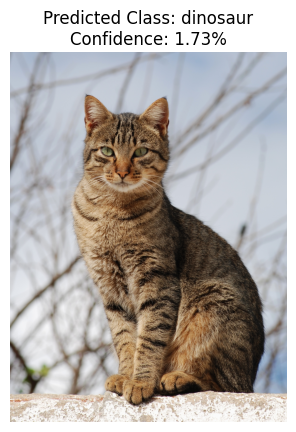

In [ ]:
image = cv2.imread("/content/cat.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

input_image = transform(image)
input_image = input_image.unsqueeze(0)
input_image = input_image.to(device)

with torch.no_grad():
    outputs = loaded_net(input_image)
_, predicted = torch.max(outputs, 1)

predicted_class = classes[predicted.item()]


confidence = torch.softmax(outputs, dim=1)[0][predicted.item()].item()

plt.imshow(image)
plt.title(f'Predicted Class: {predicted_class}\nConfidence: {confidence * 100:.2f}%')
plt.axis('off')
plt.show()

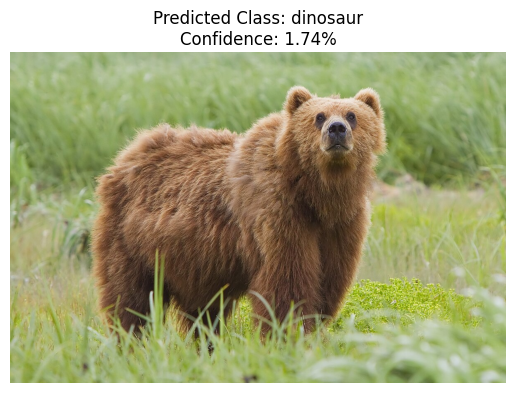

In [ ]:
image = cv2.imread("/content/bear.jpg")
image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

input_image = transform(image)
input_image = input_image.unsqueeze(0)  # Add a batch dimension
input_image = input_image.to(device)# Move the input to the GPU if available

with torch.no_grad():
    outputs = loaded_net(input_image)  # Unsqueeze to add batch dimension
_, predicted = torch.max(outputs, 1)


predicted_class = classes[predicted.item()]

# Get the prediction confidence
confidence = torch.softmax(outputs, dim=1)[0][predicted.item()].item()

# # Show the image and prediction
plt.imshow(image)
plt.title(f'Predicted Class: {predicted_class}\nConfidence: {confidence * 100:.2f}%')

plt.axis('off')
plt.show()